# Lab 1 Task 2

> Since last run is not original resnet so I rerun the original w/ data augmentation the output of this notebook is run after the report might not fully match the report
 

In [1]:
!pip install thop -q
!pip install torchsummary tensorboard ipywidgets jupyter -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import argparse
import os
import numpy as np
from torch.utils.data import random_split
from torch.utils.tensorboard import SummaryWriter
from thop import profile
from torchsummary import summary
from tqdm.notebook import tqdm

In [3]:
# Check if CUDA is available
print(torch.cuda.is_available())

True


In [4]:
# Calculate mean and std of dataset
def get_mean_std(dataset, ratio=1):
    # Get mean and std by sample ratio
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=int(len(dataset)*ratio), shuffle=True, num_workers=2)

    data = next(iter(dataloader))[0]     # get the first iteration data
    mean = np.mean(data.numpy(), axis=(0,2,3))
    std = np.std(data.numpy(), axis=(0,2,3))
    return mean, std

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())

train_mean, train_std = get_mean_std(train_dataset)
test_mean, test_std = train_mean, train_std
print(train_mean, train_std)
print(test_mean, test_std)

Files already downloaded and verified
Files already downloaded and verified
[0.49139866 0.4821593  0.44652918] [0.24703237 0.24348596 0.2615881 ]
[0.49139866 0.4821593  0.44652918] [0.24703237 0.24348596 0.2615881 ]


In [ ]:
# ##### data augmentation & normalization #####
# transform_train = transforms.Compose(
#     [
#         # 同學實作部分：Add data augmentation here
#         transforms.RandomCrop(32, padding=4),
#         transforms.RandomHorizontalFlip(p=0.5),  # 以 50% 機率做水平翻轉
#         transforms.ToTensor(),  # Transform to tensor
#         transforms.Normalize(mean=train_mean, std=train_std),  # Normalization
#     ]
# )

# transform_test = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(mean=test_mean, std=test_std),
# ])

## Jitter + RandomRotation測試

In [5]:
transform_train = transforms.Compose(
    [
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize(mean=train_mean, std=train_std),
        transforms.RandomErasing(
            p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3)
        ),  # 隨機抹除局部區域
    ]
)

transform_test = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=test_mean, std=test_std),
    ]
)

In [6]:
# Dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
test_ds = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

image, label = trainset[0]
print("image shape: ", image.shape)

# Split validation dataset
torch.manual_seed(43)     # Ensure reproducibility
val_size = 5000       # Take 5000 images as validation set
train_size = len(trainset) - val_size
train_ds, val_ds = random_split(trainset, [train_size, val_size])
print("train length: ", len(train_ds))
print("val length: ", len(val_ds))
print("test length: ", len(test_ds))

# Declare batch size
# 學生實作部分：Set batch size
BATCH_SIZE = 64
trainloader = torch.utils.data.DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Files already downloaded and verified
Files already downloaded and verified
image shape:  torch.Size([3, 32, 32])
train length:  45000
val length:  5000
test length:  10000


#### ✅ 改良版本：CIFAR 專用 ResNet-18

In [ ]:
# # ✅ 改良版本：CIFAR 專用 ResNet-18
# # 調整 conv1 與 maxpool 以保留更多特徵空間 (不再 stride=2)

# class BasicBlock(nn.Module):
#     expansion = 1
#     def __init__(self, in_channels, out_channels, stride=1):
#         super(BasicBlock, self).__init__()
#         # --- 基本兩層 3×3 卷積 + BN ---
#         self.conv1 = nn.Conv2d(in_channels, out_channels,
#                                kernel_size=3, stride=stride,
#                                padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(out_channels)
#         self.conv2 = nn.Conv2d(out_channels, out_channels,
#                                kernel_size=3, stride=1,
#                                padding=1, bias=False)
#         self.bn2 = nn.BatchNorm2d(out_channels)

#         # --- shortcut 分支：維度不符時使用 1×1 卷積調整 ---
#         self.shortcut = nn.Sequential()
#         if stride != 1 or in_channels != out_channels:
#             self.shortcut = nn.Sequential(
#                 nn.Conv2d(in_channels, out_channels,
#                           kernel_size=1, stride=stride, bias=False),
#                 nn.BatchNorm2d(out_channels)
#             )

#     def forward(self, x):
#         out = F.relu(self.bn1(self.conv1(x)))
#         out = self.bn2(self.conv2(out))
#         out += self.shortcut(x)
#         out = F.relu(out)
#         return out


# class ResNet18(nn.Module):
#     def __init__(self, num_classes=10):
#         super(ResNet18, self).__init__()
#         # --- CIFAR 版本調整重點 ---
#         # 將 conv1 改成 3×3, stride=1, padding=1
#         # 並移除 MaxPool，避免過度下採樣 (32→8)
#         self.in_channels = 64
#         self.conv1 = nn.Conv2d(3, 64, kernel_size=3,
#                                stride=1, padding=1, bias=False)
#         self.bn1 = nn.BatchNorm2d(64)
#         self.relu = nn.ReLU(inplace=True)
#         self.maxpool = nn.Identity()  # ❌ 不再使用 MaxPool

#         # --- 四層 ResNet 區塊 ---
#         self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
#         self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
#         self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
#         self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

#         # --- 平均池化 + 全連接層 ---
#         self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
#         self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

#     def _make_layer(self, block, out_channels, num_blocks, stride):
#         layers = []
#         layers.append(block(self.in_channels, out_channels, stride))
#         self.in_channels = out_channels * block.expansion
#         for _ in range(1, num_blocks):
#             layers.append(block(self.in_channels, out_channels))
#         return nn.Sequential(*layers)


#     def forward(self, x):
#         out = self.relu(self.bn1(self.conv1(x)))
#         out = self.maxpool(out)
#         out = self.layer1(out)
#         out = self.layer2(out)
#         out = self.layer3(out)
#         out = self.layer4(out)
#         out = self.avgpool(out)
#         out = torch.flatten(out, 1)
#         out = self.fc(out)
#         return out


#### 原版ResNet-18

In [7]:

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        # 學生實作部分：Define the two convolutional layers and the shortcut connection
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        # 第二層卷積
        self.conv2 = nn.Conv2d(
            out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        # 學生實作部分：Define the forward pass using convolutional layers and the shortcut connection
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet18, self).__init__()
        # 學生實作部分：Define the ResNet-18 architecture using BasicBlock
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 四個 layer 對應 conv2_x ~ conv5_x
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)  # conv2_x
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)  # conv3_x
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)  # conv4_x
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)  # conv5_x

        # 平均池化 + 全連接層
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * BasicBlock.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        # 學生實作部分：Define make_layer function to create layers of blocks
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels * block.expansion
        # 之後的 block stride=1
        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        # 學生實作部分：Define the forward pass of ResNet-18
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [8]:
# Create SummaryWriter
writer = SummaryWriter("../tensorboard")

model = ResNet18(num_classes=10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
# Print model summary
summary(model, (3, 224, 224))

# Calculate FLOPs and Params
dummy_input = torch.randn(1, 3, 32, 32).to(device)
flops, params = profile(model, inputs=(dummy_input, ))
print(f"FLOPs: {flops/1e6:.2f} MFLOPs")
print(f"Params: {params/1e6:.2f} M")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
            Conv2d-7           [-1, 64, 56, 56]          36,864
       BatchNorm2d-8           [-1, 64, 56, 56]             128
        BasicBlock-9           [-1, 64, 56, 56]               0
           Conv2d-10           [-1, 64, 56, 56]          36,864
      BatchNorm2d-11           [-1, 64, 56, 56]             128
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
       BasicBlock-14           [-1, 64,

In [9]:
# Setting parameter
EPOCH = 80
pre_epoch = 0
lr = 1e-3

# 同學可以根據自己需求調整optimizer, criterion與lr_scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCH, eta_min=1e-5)

best_model_path = 'best_resnet18.pth'

# Record training and validation metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

# Training and validation loop
for epoch in tqdm(
    range(pre_epoch, EPOCH), desc="Training Progress", colour="blue", leave=False
):  # ========== Training ==========
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    # 學生實作部分：Complete the training and validation loop
    for inputs, targets in tqdm(
        trainloader, desc=f"Train Epoch {epoch+1}", colour="green", leave=False
    ):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

    train_loss = running_loss / total
    train_acc = 100.0 * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ========== Validation ==========
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in tqdm(valloader, desc=f"Val Epoch {epoch+1}", colour="red", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            val_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    val_loss /= val_total
    val_acc = 100.0 * val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step()

    # 儲存最佳模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch [{epoch+1}/{EPOCH}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
print(f"✅ 訓練完成，最佳驗證準確率: {best_val_acc:.2f}%")

Training Progress:   0%|          | 0/80 [00:00<?, ?it/s]

Train Epoch 1:   0%|          | 0/704 [00:00<?, ?it/s]

Val Epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [1/80] Train Loss: 1.7293 | Train Acc: 36.80% | Val Loss: 1.6036 | Val Acc: 42.06%


Train Epoch 2:   0%|          | 0/704 [00:00<?, ?it/s]

...

Val Epoch 79:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [79/80] Train Loss: 0.3341 | Train Acc: 88.20% | Val Loss: 0.6055 | Val Acc: 80.98%


Train Epoch 80:   0%|          | 0/704 [00:00<?, ?it/s]

Val Epoch 80:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch [80/80] Train Loss: 0.3326 | Train Acc: 88.14% | Val Loss: 0.5666 | Val Acc: 81.72%
✅ 訓練完成，最佳驗證準確率: 81.78%


In [10]:
# Load the best model and evaluate on the test set
model.load_state_dict(torch.load(best_model_path))
model.eval()

test_correct = 0
test_total = 0
with torch.no_grad():
    for test_inputs, test_labels in testloader:
        test_inputs, test_labels = test_inputs.to(device), test_labels.to(device)
        test_outputs = model(test_inputs)
        _, test_predicted = test_outputs.max(1)
        test_total += test_labels.size(0)
        test_correct += test_predicted.eq(test_labels).sum().item()
test_accuracy = 100. * test_correct / test_total
print(f"Best Model Test Accuracy: {test_accuracy:.2f}%")

/tmp/ipykernel_16701/4135465078.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


Best Model Test Accuracy: 85.70%


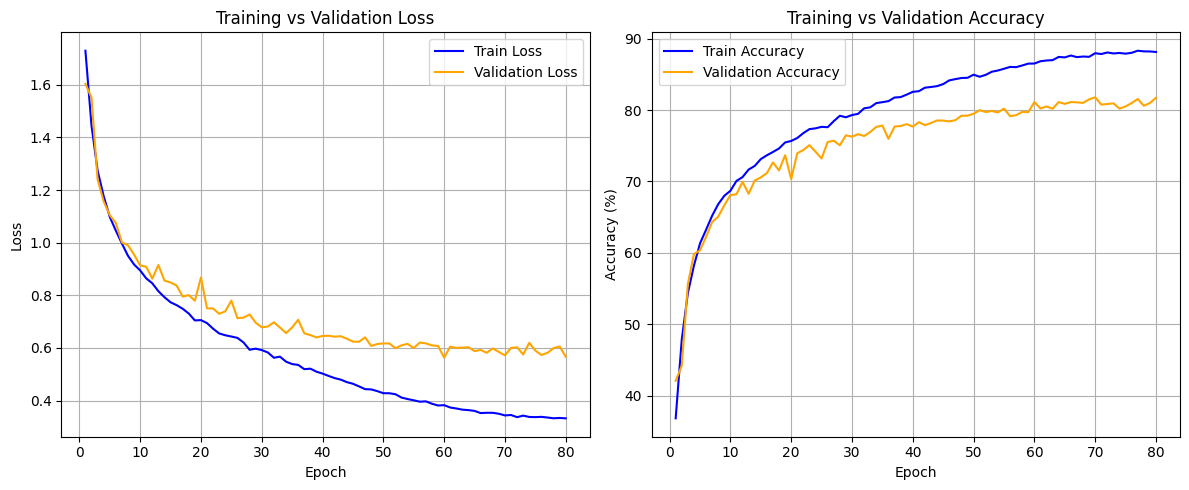

In [11]:
##### Plot loss & accuracy graph #####
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)  # ✅ 用實際長度

plt.figure(figsize=(12, 5))

# 📉 Loss 曲線
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss", color="blue")
plt.plot(epochs, val_losses, label="Validation Loss", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# 📈 Accuracy 曲線
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy", color="blue")
plt.plot(epochs, val_accuracies, label="Validation Accuracy", color="orange")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()